In [ ]:
# Modules used for data handling.
import pandas as pd
import numpy as np
from numpy import expand_dims

# Modules used for data visualization.
import seaborn as sns
import matplotlib.pyplot as plt

# Module used to perform random choice from an iterable.
import random as r

# Modules used to build the MLP architecture
import keras
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, Activation, MaxPooling2D, Conv2D, UpSampling2D, Input
from keras.datasets import mnist

sns.set_style("whitegrid")

In [ ]:
class Dataset:

    def __init__(self):
        self.x_train = None
        self.y_train = None
        self.x_test = None
        self.y_test = None

    def load_dataset(self):
        (self.x_train, self.y_train), (self.x_test, self.y_test) = mnist.load_data()

    def show_samples(self):
        rows = 3
        columns = 8
        fig, axs = plt.subplots(rows, columns,figsize=(8,8))
        for i in range(rows):
            for j in range(columns):
                axs[i,j].imshow(r.choice(self.x_train),cmap='gray')
        fig.suptitle("Image Samples of MNIST dataset")
        plt.subplots_adjust(bottom=0.5, top=0.9, hspace=0)
        plt.show()

In [ ]:
d = Dataset()

In [ ]:
d.load_dataset()

In [ ]:
# 1. Normalize pixel values from [0, 255] → [0.0, 1.0]
d.x_train = d.x_train.astype('float32') / 255.0
d.x_test  = d.x_test.astype('float32')  / 255.0

# 2. Add channel dimension: (N, 28, 28) → (N, 28, 28, 1)
# Required because Conv2D expects a channel axis
d.x_train = d.x_train.reshape(-1, 28, 28, 1)
d.x_test  = d.x_test.reshape(-1, 28, 28, 1)

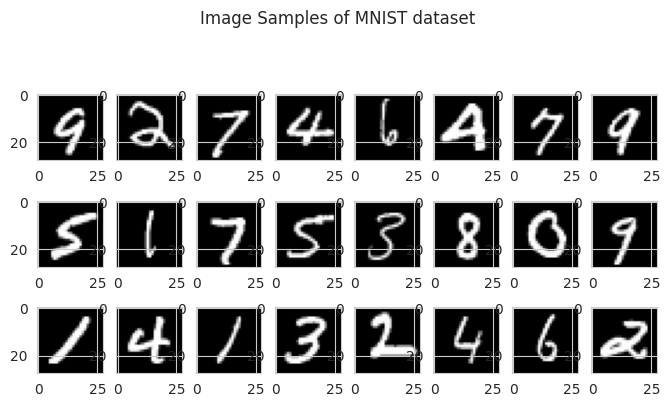

In [ ]:
d.show_samples()

In [ ]:
class Autoencoder:

    def __init__(self, x_train, y_train, x_test, y_test):
        self.x_train = x_train
        self.y_test = y_test
        self.y_train = y_train
        self.x_test = x_test
        self.IMG_DIM = (28,28,1)
        self.x = None

    def design_encoder(self):
        self.input = Input(shape=(28, 28, 1))
        self.x = Conv2D(filters = 16, kernel_size = (3, 3), activation='relu', padding='same')(self.input)
        self.x = MaxPooling2D(pool_size = (2, 2), padding='same')(self.x)

        self.x = Conv2D(filters = 8, kernel_size = (3, 3), activation='relu', padding='same')(self.x)
        self.x = MaxPooling2D(pool_size = (2, 2), padding='same')(self.x)

        self.x = Conv2D(filters = 8, kernel_size = (3, 3), activation='relu', padding='same')(self.x)
        self.encoded = MaxPooling2D(pool_size = (2, 2), padding='same')(self.x)

    def design_decoder(self):
        self.x = Conv2D(8, (3, 3), activation='relu', padding='same')(self.encoded)
        self.x = UpSampling2D((2, 2))(self.x)

        self.x = Conv2D(8, (3, 3), activation='relu', padding='same')(self.x)
        self.x = UpSampling2D((2, 2))(self.x)

        self.x = Conv2D(16, (3, 3), activation='relu')(self.x)
        self.x = UpSampling2D((2, 2))(self.x)
        self.decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(self.x)

    def compile_model(self):
        self.model = keras.models.Model(self.input, self.decoded)
        self.model.compile(optimizer='adam', loss='binary_crossentropy')

    def fit_model(self):
        self.model.fit(self.x_train, self.x_train,
                epochs=50,
                batch_size=128,
                shuffle=True,
                validation_data=(self.x_test, self.x_test)
        )


In [ ]:
a = Autoencoder(d.x_train, d.y_train, d.x_test, d.y_test)

In [ ]:
a.design_encoder()

In [ ]:
a.design_decoder()

In [ ]:
a.compile_model()

In [ ]:
a.fit_model()

Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.2084 - val_loss: 0.1460
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1352 - val_loss: 0.1253
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1223 - val_loss: 0.1177
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1165 - val_loss: 0.1132
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1130 - val_loss: 0.1105
Epoch 6/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.1105 - val_loss: 0.1082
Epoch 7/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1086 - val_loss: 0.1068
Epoch 8/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1070 - val_loss: 0.1050
Epoch 9/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1056 - val_loss: 0.1037
Epoch 10/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1045 - val_loss: 0.1026
Epoch 11/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1035 - val_loss: 0.1018
Epoch 12/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/st

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


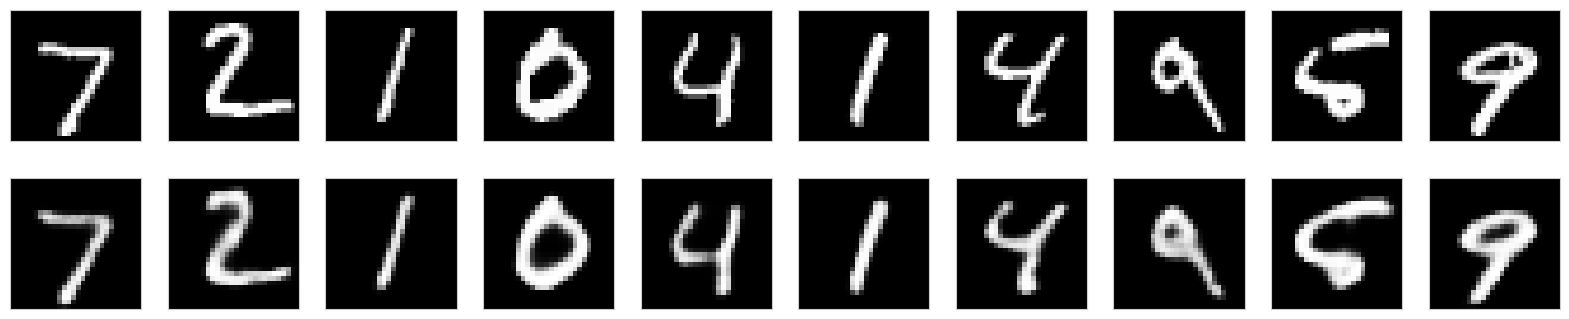

In [ ]:
decoded_imgs = a.model.predict(a.x_test)

n = 10

plt.figure(figsize=(20, 4))
for i in range(n):
    # display original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(a.x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # display reconstruction
    ax = plt.subplot(2, n, i+1+n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()